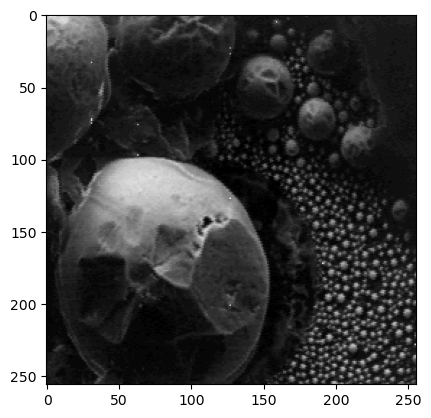

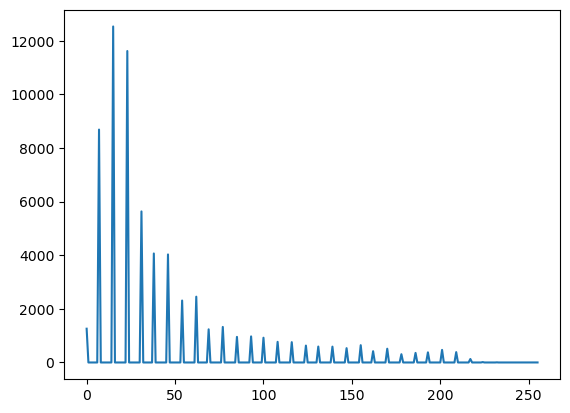

In [33]:
import cv2
import matplotlib.pyplot as plt

meb = cv2.imread('MEB.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(meb, cmap='gray', vmin=0, vmax=255)
plt.show()
histM = cv2.calcHist([meb],[0],None,[256],[0,256])
plt.plot(histM)
plt.show()


### Describa su forma: ¿es continuo/discontinuo?, ¿cuántos niveles de gris diferentes tiene?, ¿cuáles son estos niveles de gris?

Al ver el histograma de la imagen, podemos contar 29 picos que verían an tamaño y van desde el nivel 0 hasta aproximadamente el 215. Estos picos parecen estar siguiento una frecuencia cuyos valores se asemejan a la tabla del 8, siendo los niveles aproximados de gris presentes 0, 8, 16, 24, 32, 40, 48, 56, 64, 72, 80, etc.

In [34]:
import numpy as np

unique_values = np.unique(meb)
num_unique_values = len(unique_values)
print(f"# Niveles de gris: {num_unique_values}")
print(f"Niveles de gris: {unique_values}")

# Niveles de gris: 34
Niveles de gris: [  0   7  15  23  31  38  46  54  62  69  77  85  93 100 108 116 124 131
 139 147 155 162 170 178 186 193 201 209 217 224 232 240 248 255]


### Deduzca con cuántos bits ha sido numerizada esta imagen.

En una imágen de 8 bits, los niveles de gris van de 0 a 255, permitiendo 256 valores diferentes. Si solo vemos el histograma, la imágen tiene aproximadamente 29 niveles de gris. Para determinar los bits de cuantización, usamos la fórmula N = 2^b donde "N" es la cantidad de niveles de gris distintos y "b" es el número de bits utilizados. La potencia de 2 más cercana a 29 es 32, entonces si resolvemos 2^b = 32 veremos que b = \log_2(32) = 5 bits. Si queremos ser más precisos, podemos calcular la cantidad de niveles de grs exactos y cuáles son. En este caso la cantidad real de niveles de gris es 34 y nuevamente la potencia de 2 más cercana es 32, entonces se confirma que la imágen sido digitalizada con 5 bits. 

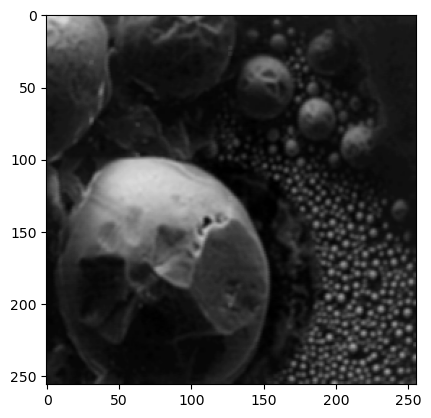

In [35]:
from skimage.filters.rank import mean
from skimage.morphology import square 

mascara = square(3)
mebS = mean(meb, mascara)
plt.imshow(mebS, cmap='gray', vmin=0, vmax=255)
plt.show()


### ¿cómo es la imagen resultado? 

El filtro promedio de 3 X 3 suaviza ligeramente la imagen, reduciendo el ruido y las variaciones locales de intensidad. Sin embargo, los bordes pueden perder algo de nitidez y verse borrosos. En general, la imagen se ve un poco más difuminada.


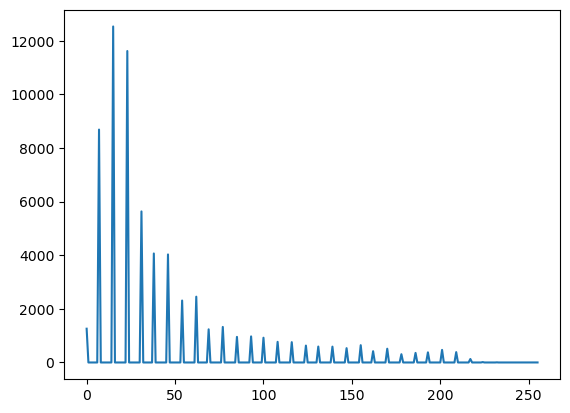

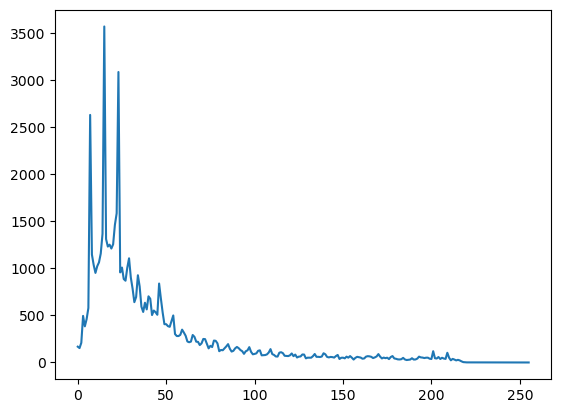

In [36]:
plt.plot(histM)
plt.show()

histMS = cv2.calcHist([mebS],[0],None,[256],[0,256])
plt.plot(histMS)
plt.show()

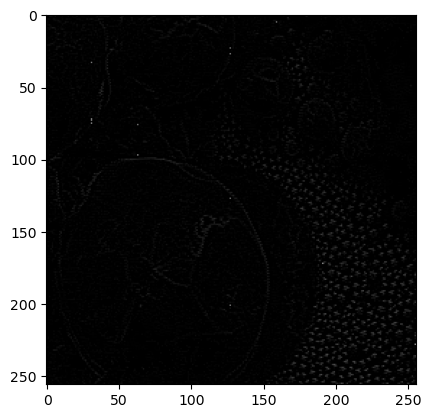

In [37]:
diferencia = cv2.subtract(meb, mebS)
plt.imshow(diferencia, cmap='gray', vmin=0, vmax=255)
plt.show()

### Justifique el resultado obtenido. ¿en cuáles regiones de la imagen son visibles las diferencias?, ¿por qué?

Como podemos ve en la imagen, las diferencias son más evidentes en los bordes y los detalles de la imagen. Las zonas que son homogéneas serán menos evidentes porque el filtro apenas las modifica. Esto afecta más que todo a los bordes y detalles pequeños porque el filtro reemplaza cada píxel con el promedio de su vecindario, lo que tiende a difuminar los contrastes. En la imagen de diferencia, estas áreas aparecen más brillantes, indicando dónde hubo más cambios.


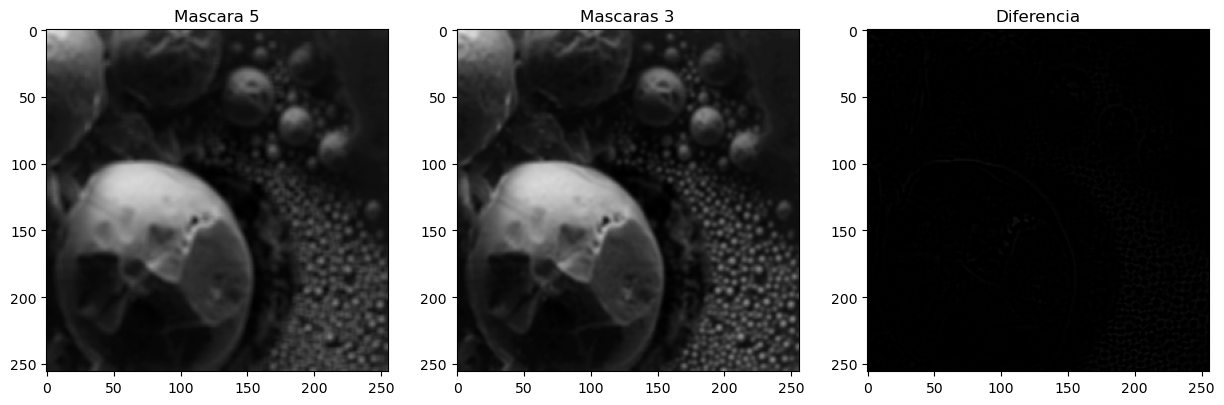

In [38]:
mascara1 = square(5)
mascara2 = square(3)

mebS5 = mean(meb, mascara1)
mebS3 = mean(meb, mascara2)
mebS33 = mean(mebS3, mascara2)
diferencia533 = cv2.subtract(mebS5, mebS33)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(mebS5, cmap='gray', vmin=0, vmax=255)
plt.title("Mascara 5")
plt.subplot(1, 3, 2)
plt.imshow(mebS33, cmap='gray', vmin=0, vmax=255)
plt.title("Mascaras 3")
plt.subplot(1, 3, 3)
plt.imshow(diferencia533, cmap='gray', vmin=0, vmax=255)
plt.title("Diferencia")
plt.show()

### Haga una evaluación visual de los resultados: ¿las dos imágenes obtenidas son idénticas? ¿por qué? ¿cuál de los dos tratamientos suprime mejor los cambios de nivel de gris de la imagen?

Aunque son casi iguales, las 2 imágenes no son exactamente idénticas. La aplicación de dos filtros 3x3 no es equivalente a un único filtro 5x5, aunque ambos suavizan la imagen en un nivel similar. Incluso podemos ver que en la diferencia casi no se ve nada a excepción de un par de manchas casi imperceptible. El filtro 5x5 promedia directamente los valores en una ventana más grande mientras que el filtro 3x3 aplicado dos veces primero suaviza la imagen y luego vuelve a suavizarla, lo que genera un efecto de propagación del suavizado. Matemáticamente, aplicar un 3x3 dos veces es más similar a un filtro Gaussiano, mientras que el 5x5 es un promedio más uniforme. El filtro 5x5 suprime mejor los cambios de nivel de gris porque abarca un área más grande de la imagen en una sola operación, generando una suavización más fuerte. La aplicación sucesiva de dos filtros 3x3 suaviza de manera progresiva, pero no de forma tan uniforme como el 5x5.

### ¿Cuál es entonces la máscara resultante de la convolución de la máscara del filtro promedio 3x3 con ella misma? ¿Cómo es la máscara del filtro promedio 5x5? Con base en la forma de estas dos máscaras, justifique los resultados visuales obtenidos en el punto anterior.

Aplicar dos veces un filtro promedio 3x3 equivale a una convolución con una nueva máscara 5x5, cuyos valores siguen un patrón similar a una distribución Gaussiana, dando más peso al centro y menos a los bordes. En contraste, el filtro promedio 5x5 estándar trata todos los píxeles por igual, generando un suavizado más uniforme pero también más agresivo. Como resultado, la imagen filtrada con dos 3x3 mantiene más detalles y transiciones suaves, mientras que la filtrada con un solo 5x5 elimina más información y se ve más borrosa.

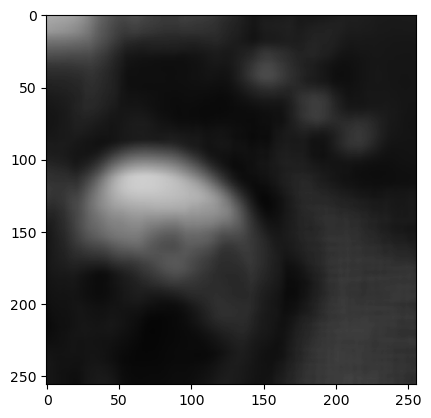

In [39]:
mascara25 = square(25)
mebS25 = mean(meb, mascara25)
plt.imshow(mebS25, cmap='gray', vmin=0, vmax=255)
plt.show()

### ¿qué objetos de la imagen original se conservaron?¿qué sucedió con las estructuras pequeñas presentes en la imagen original?¿por qué?

Cuando aplicamos un filtro promedio con una máscara de 25x25, el suavizado es mucho más intenso porque se promedia un área mucho más grande en cada píxel. Podemos ver que de la imagen original solo quedan las esferas de un tamaño considerable pero con un menor contraste mientras que las esferas meas pequeñas e insignificantes que hacían parte del fondo difuminaron y desaparecieron sus bordes al ser absorbidos por el promedio de un área extensa. Esto pasa porque al aumentar el tamaño de la máscara, el filtro elimina gradientes locales y texturas finas, dejando solo variaciones de intensidad amplias y uniformes. Es un efecto similar a aplicar un desenfoque muy fuerte.  

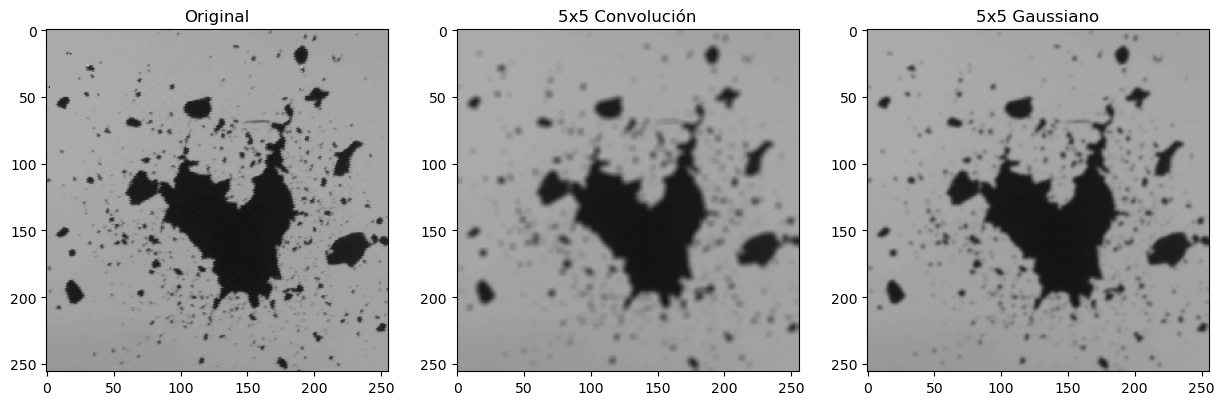

In [40]:
impact = cv2.imread('IMPACT.png', cv2.IMREAD_GRAYSCALE)

kernel = np.ones((5,5), np.float32) / 25
impactC = cv2.filter2D(impact, -1, kernel)

kernel_gaussiano = cv2.getGaussianKernel(5, sigma=1)
kernel_gaussiano = np.outer(kernel_gaussiano, kernel_gaussiano)
impactG = cv2.filter2D(impact, -1, kernel_gaussiano)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(impact, cmap='gray', vmin=0, vmax=255)
plt.title("Original")
plt.subplot(1, 3, 2)
plt.imshow(impactC, cmap='gray', vmin=0, vmax=255)
plt.title("5x5 Convolución")
plt.subplot(1, 3, 3)
plt.imshow(impactG, cmap='gray', vmin=0, vmax=255)
plt.title("5x5 Gaussiano")
plt.show()

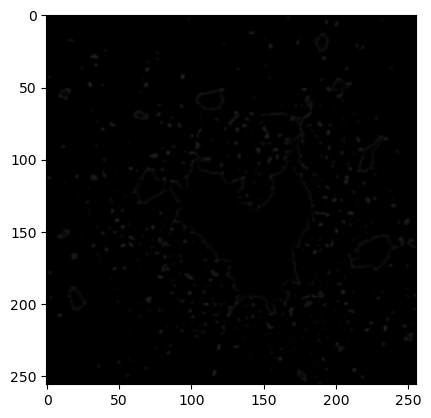

In [41]:
diferencia5CG = cv2.subtract(impactC, impactG)
plt.imshow(diferencia5CG, cmap='gray', vmin=0, vmax=255)
plt.show()


### Justifique el resultado obtenido (¿en cuáles regiones de la imagen son visibles las diferencias?, ¿por qué?...).

Podemos ver que las regiones de la imagen donde se hace visibe la diferencia son las zonas con bordes o detalles finos porque el la Gaussiana maneja el filtrado de manera más precisa en los bordes. La diferencia es pequeña porque ambos métodos aplican el mismo principio de suavizado, pero pueden manejar el rango de valores de forma distinta. En regiones planas o uniformes, la diferencia es casi nula y nos permite denotar levemente la figura de la mancha original en la diferencia.

### ¿ En qué casos (características de las imágenes) preferiría utilizar un filtro promedio a un filtro gaussiano y visceversa?

El filtro promedio se usa para eliminar ruido uniforme y es computacionalmente eficiente, pero puede generar pérdida de detalles. En cambio, el filtro gaussiano es mejor para imágenes con ruido, ya que suaviza de manera más natural sin afectar tanto los bordes. Si se necesita un suavizado rápido, el filtro promedio es una opción, mientras que el filtro gaussiano es preferible cuando se busca una reducción de ruido más efectiva.